<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [2]:
# Download the database (Windows version)
import urllib.request
urllib.request.urlretrieve("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite", "survey-results-public.sqlite")

# Install and import
!pip install pandas
!pip install matplotlib

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Open the door to the database
conn = sqlite3.connect('survey-results-public.sqlite')

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [3]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [4]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [5]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


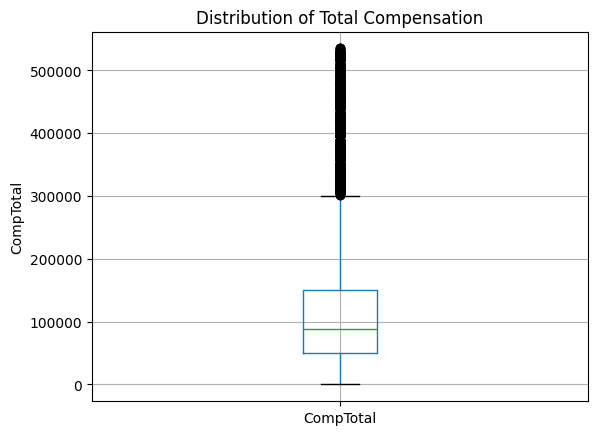

In [6]:
# Get the data
QUERY = """
SELECT CompTotal FROM main
WHERE CompTotal IS NOT NULL
"""
df1 = pd.read_sql_query(QUERY, conn)

# Remove outliers so the chart isn't squished
Q1 = df1['CompTotal'].quantile(0.25)
Q3 = df1['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df1_clean = df1[(df1['CompTotal'] >= lower) & (df1['CompTotal'] <= upper)]

# Draw the box plot
df1_clean.boxplot(column='CompTotal')
plt.title("Distribution of Total Compensation")
plt.ylabel("CompTotal")
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


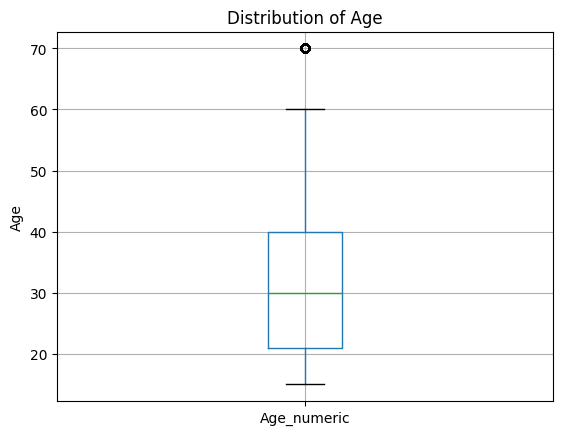

In [7]:
# Get the data
QUERY = """
SELECT Age FROM main
WHERE Age IS NOT NULL
"""
df2 = pd.read_sql_query(QUERY, conn)

# Turn Age words into numbers
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': 25
}
df2['Age_numeric'] = df2['Age'].map(age_map)

# Draw the box plot
df2.boxplot(column='Age_numeric')
plt.title("Distribution of Age")
plt.ylabel("Age")
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


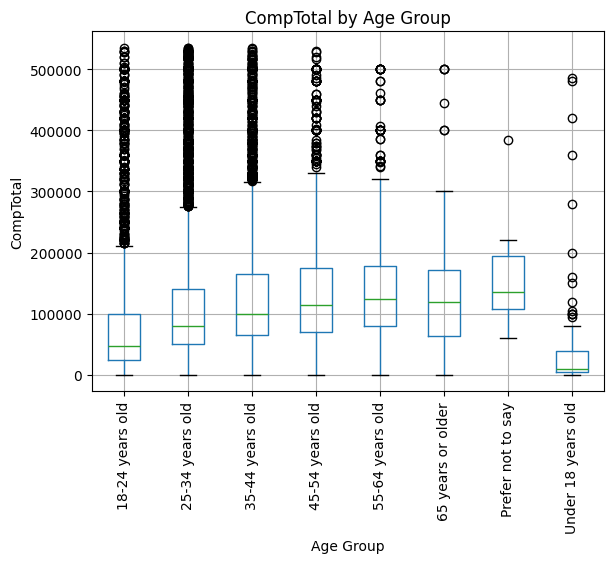

In [8]:
# Get the data
QUERY = """
SELECT Age, CompTotal FROM main
WHERE Age IS NOT NULL
AND CompTotal IS NOT NULL
"""
df3 = pd.read_sql_query(QUERY, conn)

# Remove outliers
Q1 = df3['CompTotal'].quantile(0.25)
Q3 = df3['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df3 = df3[(df3['CompTotal'] >= lower) & (df3['CompTotal'] <= upper)]

# Draw box plots grouped by Age
df3.boxplot(column='CompTotal', by='Age')
plt.title("CompTotal by Age Group")
plt.suptitle("")
plt.xlabel("Age Group")
plt.ylabel("CompTotal")
plt.xticks(rotation=90)
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


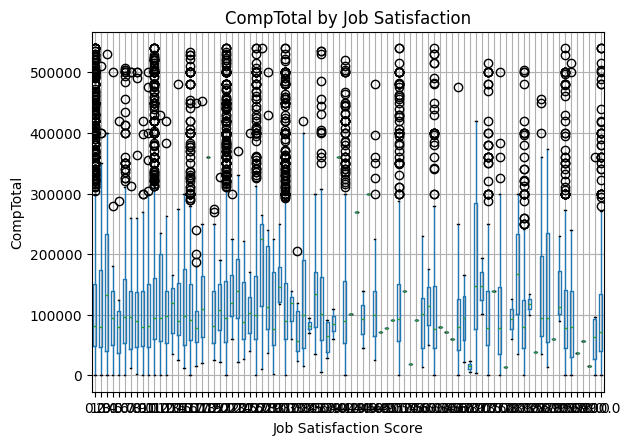

In [9]:
# Get the data
QUERY = """
SELECT JobSatPoints_6, CompTotal FROM main
WHERE JobSatPoints_6 IS NOT NULL
AND CompTotal IS NOT NULL
"""
df4 = pd.read_sql_query(QUERY, conn)

# Remove outliers
Q1 = df4['CompTotal'].quantile(0.25)
Q3 = df4['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df4 = df4[(df4['CompTotal'] >= lower) & (df4['CompTotal'] <= upper)]

# Draw box plots grouped by Job Satisfaction
df4.boxplot(column='CompTotal', by='JobSatPoints_6')
plt.title("CompTotal by Job Satisfaction")
plt.suptitle("")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("CompTotal")
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


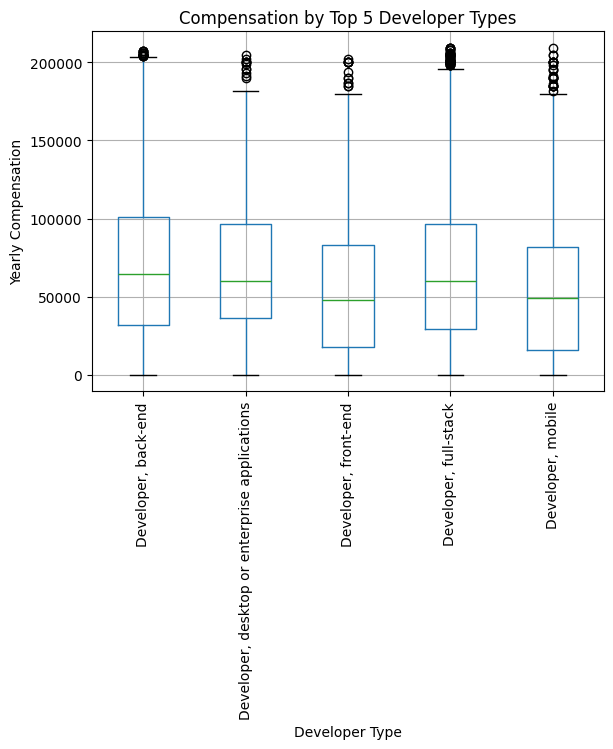

In [10]:
# Get the data
QUERY = """
SELECT DevType, ConvertedCompYearly FROM main
WHERE DevType IS NOT NULL
AND ConvertedCompYearly IS NOT NULL
"""
df5 = pd.read_sql_query(QUERY, conn)

# DevType has multiple answers separated by semicolons — split them
df5_split = df5.assign(DevType=df5['DevType'].str.split(';')).explode('DevType')

# Find the top 5 developer types
top5_devs = df5_split['DevType'].value_counts().head(5).index

# Keep only the top 5
df5_top = df5_split[df5_split['DevType'].isin(top5_devs)]

# Remove outliers
Q1 = df5_top['ConvertedCompYearly'].quantile(0.25)
Q3 = df5_top['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df5_top = df5_top[(df5_top['ConvertedCompYearly'] >= lower) & (df5_top['ConvertedCompYearly'] <= upper)]

# Draw box plots grouped by DevType
df5_top.boxplot(column='ConvertedCompYearly', by='DevType')
plt.title("Compensation by Top 5 Developer Types")
plt.suptitle("")
plt.xlabel("Developer Type")
plt.ylabel("Yearly Compensation")
plt.xticks(rotation=90)
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


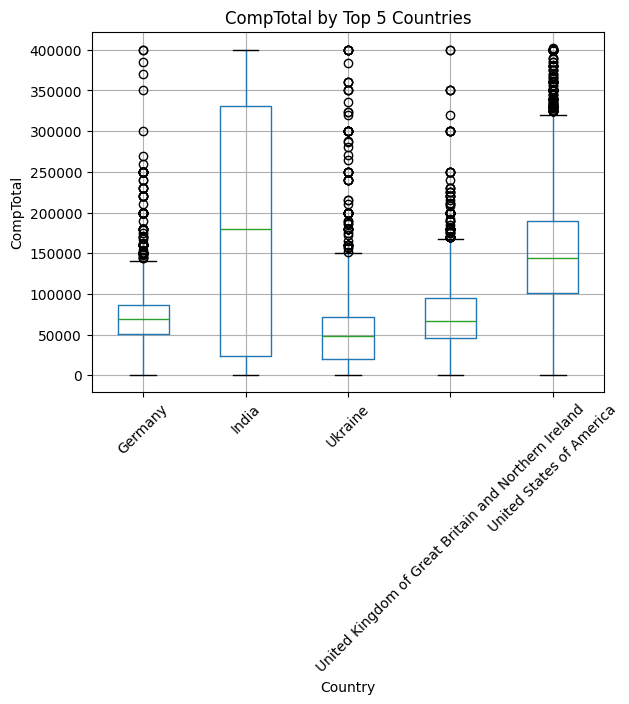

In [11]:
# Get the data
QUERY = """
SELECT Country, CompTotal FROM main
WHERE Country IS NOT NULL
AND CompTotal IS NOT NULL
"""
df6 = pd.read_sql_query(QUERY, conn)

# Find the top 5 countries
top5_countries = df6['Country'].value_counts().head(5).index

# Keep only the top 5
df6_top = df6[df6['Country'].isin(top5_countries)]

# Remove outliers
Q1 = df6_top['CompTotal'].quantile(0.25)
Q3 = df6_top['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df6_top = df6_top[(df6_top['CompTotal'] >= lower) & (df6_top['CompTotal'] <= upper)]

# Draw box plots grouped by Country
df6_top.boxplot(column='CompTotal', by='Country')
plt.title("CompTotal by Top 5 Countries")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("CompTotal")
plt.xticks(rotation=45)
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


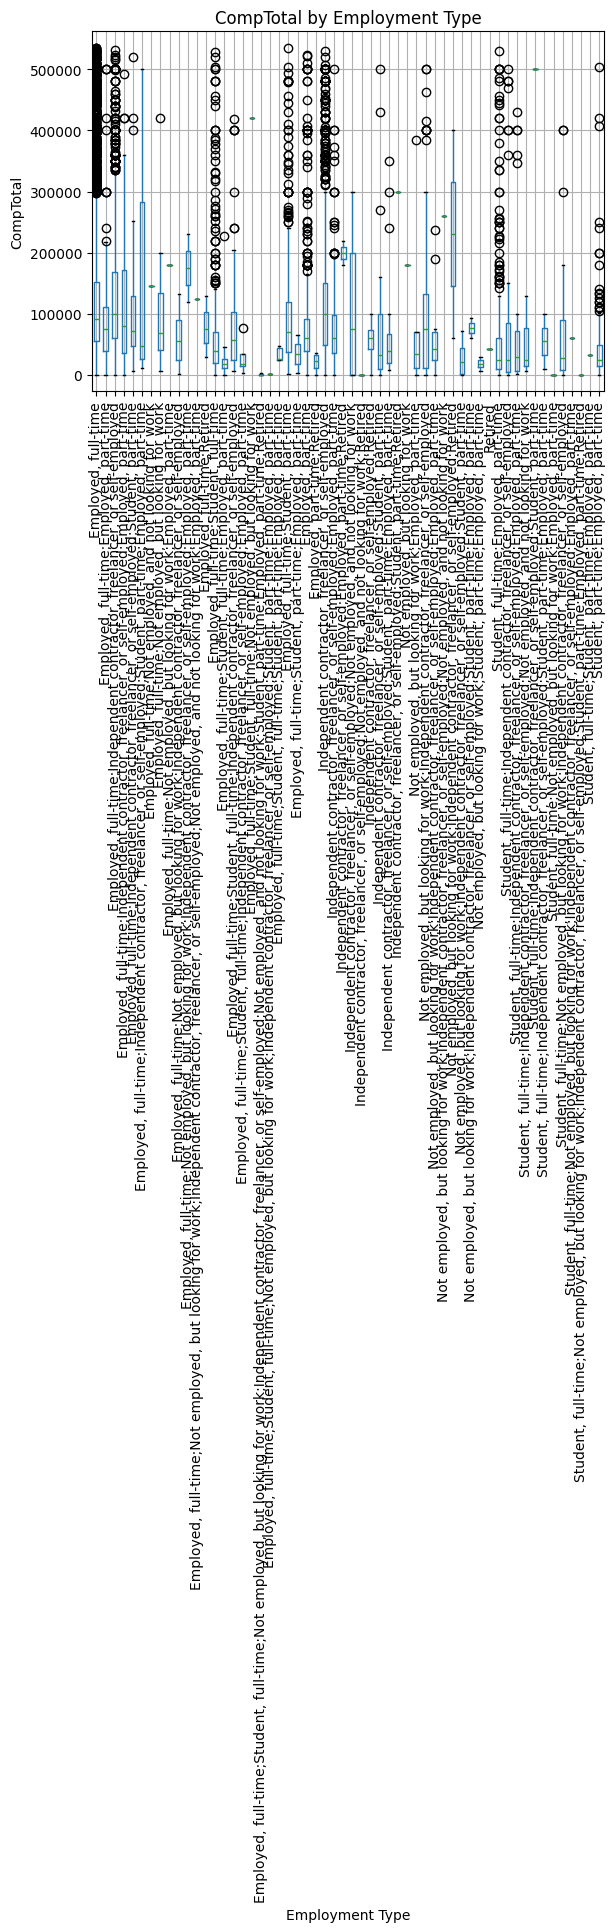

In [12]:
# Get the data
QUERY = """
SELECT Employment, CompTotal FROM main
WHERE Employment IS NOT NULL
AND CompTotal IS NOT NULL
"""
df7 = pd.read_sql_query(QUERY, conn)

# Remove outliers
Q1 = df7['CompTotal'].quantile(0.25)
Q3 = df7['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df7 = df7[(df7['CompTotal'] >= lower) & (df7['CompTotal'] <= upper)]

# Draw box plots grouped by Employment
df7.boxplot(column='CompTotal', by='Employment')
plt.title("CompTotal by Employment Type")
plt.suptitle("")
plt.xlabel("Employment Type")
plt.ylabel("CompTotal")
plt.xticks(rotation=90)
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


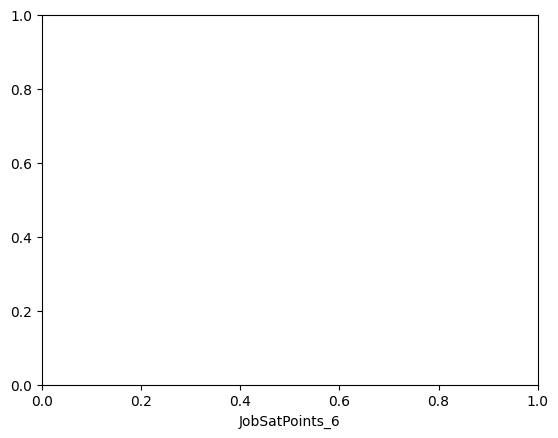

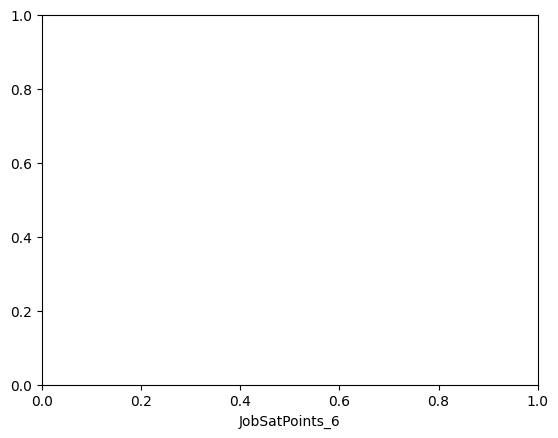

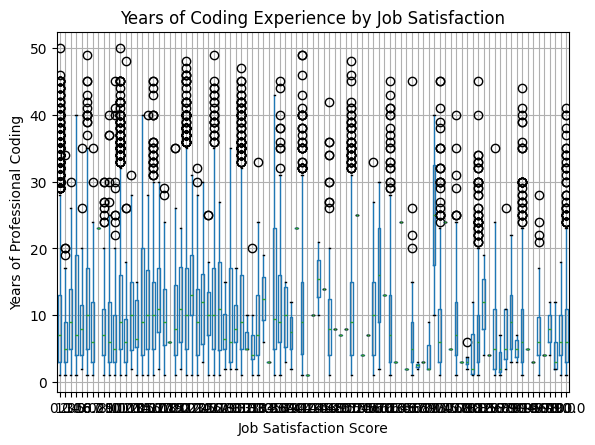

In [15]:
# Get the data
QUERY = """
SELECT JobSatPoints_6, YearsCodePro FROM main
WHERE JobSatPoints_6 IS NOT NULL
AND YearsCodePro IS NOT NULL
"""
df8 = pd.read_sql_query(QUERY, conn)

# Convert YearsCodePro to numbers (some values might be text like "Less than 1 year")
df8['YearsCodePro'] = pd.to_numeric(df8['YearsCodePro'], errors='coerce')

# Drop rows that couldn't be converted
df8 = df8.dropna()

# Draw box plots grouped by Job Satisfaction
df8.boxplot(column='YearsCodePro', by='JobSatPoints_6')
plt.title("Years of Coding Experience by Job Satisfaction")
plt.suptitle("")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Years of Professional Coding")
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [16]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
